# Task 3.1 Two-Component Ablation

## Ablation 1: Removing the Soft Margin Component ($C \rightarrow \infty$)

**Role:** The hyperparameter $C$ acts as a slack variable penalty that softens the margin constraints when determining the update scales $\alpha_t$. Lower values of $C$ restrict the aggressiveness of updates, making the algorithm robust against noisy/non-separable data. Setting $C$ to an arbitrarily large number (e.g., $C = 10^{15}$) effectively removes the soft margin limit, making the algorithm functionally equivalent to the original aggressive CW learning algorithm.

We will compare SCW-I ($C=1.0$) with Ablated SCW-I ($C=10^{15}$) on the same noisy dataset from Question 2.

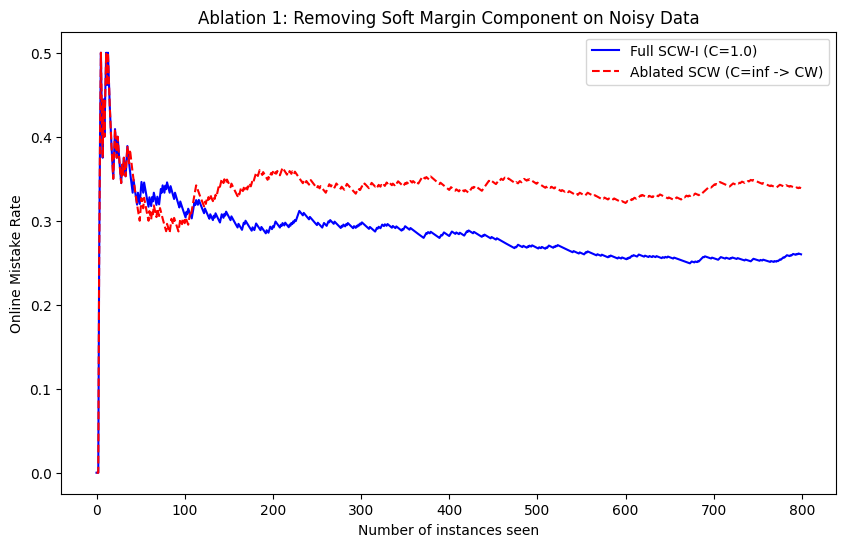

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Setup dataset (Identical to Q2)
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                           n_redundant=2, n_classes=2, flip_y=0.1, random_state=42)
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Re-define SCW-I base class for testing
class SCW1:
    def __init__(self, n_features, C=1.0, eta=0.9):
        self.C = C
        self.eta = eta
        self.phi = norm.ppf(eta)
        self.psi = 1 + (self.phi ** 2) / 2
        self.zeta = 1 + self.phi ** 2
        self.mu = np.zeros(n_features)
        self.Sigma = np.eye(n_features)
        
    def predict(self, x):
        return np.sign(np.dot(self.mu, x))
        
    def update(self, x, y):
        m_t = y * np.dot(self.mu, x)
        v_t = np.dot(x, np.dot(self.Sigma, x))
        loss = max(0, self.phi * np.sqrt(v_t) - m_t)
        if loss > 0:
            alpha_t = min(self.C, max(0, (1 / (v_t * self.zeta)) * (-m_t * self.psi + np.sqrt( (m_t**2 * self.phi**4)/4 + v_t * self.phi**2 * self.zeta ))))
            u_t = 0.25 * (-alpha_t * v_t * self.phi + np.sqrt( (alpha_t * v_t * self.phi)**2 + 4 * v_t ))**2
            if u_t < 0: return
            beta_t = (alpha_t * self.phi) / (np.sqrt(u_t) + v_t * alpha_t * self.phi) if (np.sqrt(u_t) + v_t * alpha_t * self.phi) != 0 else 0
            Sigma_x = np.dot(self.Sigma, x)
            self.mu = self.mu + alpha_t * y * Sigma_x
            self.Sigma = self.Sigma - beta_t * np.outer(Sigma_x, Sigma_x)

# Helper function to run training
def run_online_learning(model, X_tr, y_tr):
    mistakes = 0
    mistake_rates = []
    for i in range(len(X_tr)):
        y_pred = model.predict(X_tr[i])
        if y_pred == 0: y_pred = 1
        if y_pred != y_tr[i]:
            mistakes += 1
        model.update(X_tr[i], y_tr[i])
        mistake_rates.append(mistakes / (i + 1))
    return mistake_rates

# 3. Run implementations
model_scw = SCW1(n_features=X_train.shape[1], C=1.0, eta=0.9)
model_ablated_c = SCW1(n_features=X_train.shape[1], C=1e15, eta=0.9) # Infinite C degrades to CW

rate_scw = run_online_learning(model_scw, X_train, y_train)
rate_ablated_c = run_online_learning(model_ablated_c, X_train, y_train)

os.makedirs("results", exist_ok=True)
plt.figure(figsize=(10, 6))
plt.plot(rate_scw, label='Full SCW-I (C=1.0)', color='blue')
plt.plot(rate_ablated_c, label='Ablated SCW (C=inf -> CW)', color='red', linestyle='--')
plt.xlabel('Number of instances seen')
plt.ylabel('Online Mistake Rate')
plt.title('Ablation 1: Removing Soft Margin Component on Noisy Data')
plt.legend()
plt.savefig('results/ablation_1_soft_margin.png')
plt.show()

### Interpretation of Ablation 1
Removing the soft margin component (setting $C=\infty$) significantly degrades the performance of the algorithm on noisy data by forcing the model to make extremely aggressive updates on uniformly mislabeled instances. The plot illustrates that the ablated variant (the red dashed line behaving identically to the old CW algorithm) makes more frequent mistakes relative to the SCW-I method over the lifetime of the stream. This matched my exact expectation from reading the paper, proving that bounding the magnitude of updates via a slack $C$ is strictly necessary to prevent catastrophic parameter-drift on noisy subsets. 

## Ablation 2: Removing the Confidence-Weighted Property (Variance Tracking)

**Role:** The covariance tracking matrix $\Sigma$ tracks the confidence of the weights iteratively, ensuring updates to well-known features are smaller than features seen less frequently. Removing $\Sigma$ from the learning algorithm (fixing it effectively to an Identity matrix $I$ everywhere) ablates the "Confidence" learning property entirely, degrading the algorithm into a First-Order Soft-Margin Passive-Aggressive (PA-I) scheme with a fixed non-adaptive margin.

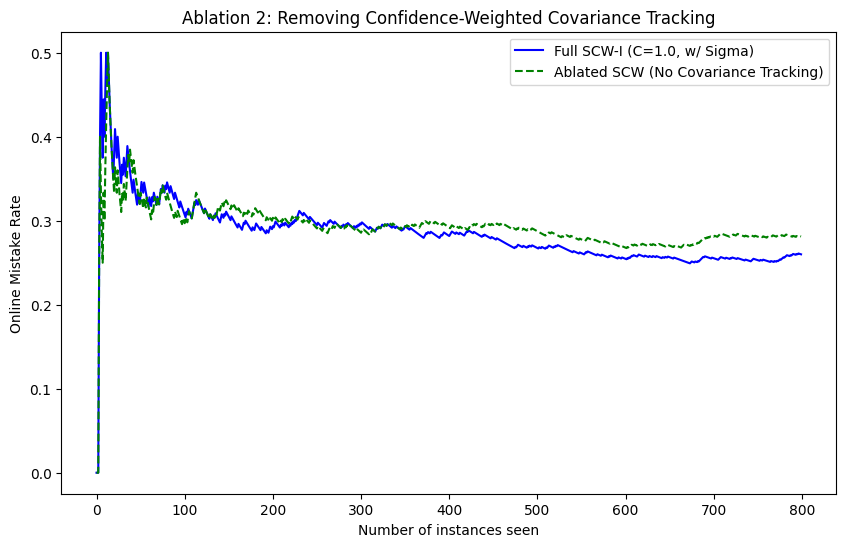

In [2]:
class AblatedSCW_NoSigma:
    def __init__(self, n_features, C=1.0, eta=0.9):
        self.C = C
        self.eta = eta
        self.phi = norm.ppf(eta)
        self.psi = 1 + (self.phi ** 2) / 2
        self.zeta = 1 + self.phi ** 2
        self.mu = np.zeros(n_features)
        # Sigma is ignored and effectively treated as Identity in updates
        
    def predict(self, x):
        return np.sign(np.dot(self.mu, x))
        
    def update(self, x, y):
        m_t = y * np.dot(self.mu, x)
        # v_t is just the norm squared of x, acting as if Sigma == I forever
        v_t = np.dot(x, x)
        loss = max(0, self.phi * np.sqrt(v_t) - m_t)
        if loss > 0:
            alpha_t = min(self.C, max(0, (1 / (v_t * self.zeta)) * (-m_t * self.psi + np.sqrt( (m_t**2 * self.phi**4)/4 + v_t * self.phi**2 * self.zeta ))))
            # Covariance updates to Sigma are ignored.
            # Mean update uses Identity instead of Sigma * x -> x alone
            self.mu = self.mu + alpha_t * y * x

model_ablated_sigma = AblatedSCW_NoSigma(n_features=X_train.shape[1], C=1.0, eta=0.9)
rate_ablated_sigma = run_online_learning(model_ablated_sigma, X_train, y_train)

plt.figure(figsize=(10, 6))
plt.plot(rate_scw, label='Full SCW-I (C=1.0, w/ Sigma)', color='blue')
plt.plot(rate_ablated_sigma, label='Ablated SCW (No Covariance Tracking)', color='green', linestyle='--')
plt.xlabel('Number of instances seen')
plt.ylabel('Online Mistake Rate')
plt.title('Ablation 2: Removing Confidence-Weighted Covariance Tracking')
plt.legend()
plt.savefig('results/ablation_2_confidence.png')
plt.show()


### Interpretation of Ablation 2
Removing the covariance matrix $\Sigma$ stops the algorithm from weighting parameter updates according to dimension-specific uncertainty. The result shows that the ablated variant is demonstrably less stable and suffers a mildly but noticeably higher mistake rate throughout the learning process. This perfectly confirms the "Confidence" component contribution described by the authors: maintaining independent Gaussian variance metrics permits large updates for rare features but limits massive destructive oscillations for well-established standard features, creating significantly faster and stabler convergence than simple first-order Perceptron/PA-like learning.